In [1]:

!pip install -q segmentation-models-pytorch


!wget --no-check-certificate https://s3.eu-central-1.amazonaws.com/avg-kitti/data_road.zip


!unzip -q data_road.zip

print("Dataset baixado e descompactado com sucesso.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00
--2026-07-18 18:02:49--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_road.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 52.219.170.249, 3.5.122.220, 52.219.171.197, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|52.219.170.249|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 470992343 (449M) [application/zip]
Saving to: ‘data_road.zip’

data_road.zip       100%[===================>] 449.17M  24.1MB/s    in 20s     

2026-07-18 18:03:09 (22.5 MB/s) - ‘data_road.zip’ saved [470992343/470992343]

Dataset baixado e descompactado com sucesso.


In [2]:

import os
import glob
import torch
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


images_path = sorted(glob.glob("data_road/training/image_2/*_*.png"))
masks_path = sorted(glob.glob("data_road/training/gt_image_2/*_road_*.png"))


train_imgs, test_imgs, train_msks, test_msks = train_test_split(images_path, masks_path, test_size=0.2, random_state=42)
val_imgs, test_imgs, val_msks, test_msks = train_test_split(test_imgs, test_msks, test_size=0.5, random_state=42)

class KittiRoadDataset(Dataset):
    def __init__(self, images, masks, img_size):
        self.images = images
        self.masks = masks
        self.img_size = img_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = cv2.imread(self.images[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        mask = cv2.imread(self.masks[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        binary_mask = (mask[:, :, 0] > 100) & (mask[:, :, 2] > 100)
        binary_mask = binary_mask.astype(np.float32)


        img = img.transpose(2, 0, 1) / 255.0
        img = torch.tensor(img, dtype=torch.float32)
        binary_mask = torch.tensor(binary_mask, dtype=torch.float32).unsqueeze(0)

        return img, binary_mask

print(f"✓ Dados mapeados! Treino: {len(train_imgs)}, Validação: {len(val_imgs)}, Teste: {len(test_imgs)}")

✓ Dados mapeados! Treino: 231, Validação: 29, Teste: 29


In [3]:
import segmentation_models_pytorch as smp

def calcular_metricas(preds, targets):
    preds = (preds > 0.5).float()

    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    tn = ((1 - preds) * (1 - targets)).sum().item()

    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)

    return iou, precision, recall, f1


def treinar_modelo(model, train_loader, val_loader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = smp.losses.DiceLoss(mode='binary')
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    historico = {'train_loss': [], 'val_loss': [], 'val_iou': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for imgs, msks in train_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, msks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()


        model.eval()
        val_loss = 0
        val_iou = 0
        with torch.no_grad():
            for imgs, msks in val_loader:
                imgs, msks = imgs.to(device), msks.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, msks)
                val_loss += loss.item()

                preds = torch.sigmoid(outputs)
                iou, _, _, _ = calcular_metricas(preds, msks)
                val_iou += iou

        epoch_train_loss = train_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_iou = val_iou / len(val_loader)

        historico['train_loss'].append(epoch_train_loss)
        historico['val_loss'].append(epoch_val_loss)
        historico['val_iou'].append(epoch_val_iou)

        print(f"Época [{epoch+1}/{epochs}] -> Perda Treino: {epoch_train_loss:.4f} | Perda Val: {epoch_val_loss:.4f} | IoU Val: {epoch_val_iou:.4f}")

    return historico

print(" Funções de treino e métricas preparadas!")

 Funções de treino e métricas preparadas!


In [8]:


print("Iniciando Experimento 1 (Imagens 256x256)...")
train_dataset_256_exp1 = KittiRoadDataset(train_imgs, train_msks, img_size=256)
val_dataset_256_exp1 = KittiRoadDataset(val_imgs, val_msks, img_size=256)

train_loader_256_exp1 = DataLoader(train_dataset_256_exp1, batch_size=4, shuffle=True)
val_loader_256_exp1 = DataLoader(val_dataset_256_exp1, batch_size=4, shuffle=False)


modelo_exp1 = smp.DeepLabV3Plus(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=1)

historico_exp1 = treinar_modelo(modelo_exp1, train_loader_256_exp1, val_loader_256_exp1, epochs=10)

Iniciando Experimento 1 (Imagens 256x256)...


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Época [1/10] -> Perda Treino: 0.4476 | Perda Val: 0.4127 | IoU Val: 0.6882
Época [2/10] -> Perda Treino: 0.2516 | Perda Val: 0.2344 | IoU Val: 0.8124
Época [3/10] -> Perda Treino: 0.1695 | Perda Val: 0.1350 | IoU Val: 0.8893
Época [4/10] -> Perda Treino: 0.1207 | Perda Val: 0.1009 | IoU Val: 0.9086
Época [5/10] -> Perda Treino: 0.0938 | Perda Val: 0.0866 | IoU Val: 0.9095
Época [6/10] -> Perda Treino: 0.0847 | Perda Val: 0.0885 | IoU Val: 0.8925
Época [7/10] -> Perda Treino: 0.0725 | Perda Val: 0.0660 | IoU Val: 0.9193
Época [8/10] -> Perda Treino: 0.0601 | Perda Val: 0.0569 | IoU Val: 0.9268
Época [9/10] -> Perda Treino: 0.0526 | Perda Val: 0.0540 | IoU Val: 0.9250
Época [10/10] -> Perda Treino: 0.0489 | Perda Val: 0.0522 | IoU Val: 0.9248


In [11]:


print("Iniciando Experimento 2 (Imagens 512x512)...")
train_dataset_512_exp2 = KittiRoadDataset(train_imgs, train_msks, img_size=512)
val_dataset_512_exp2 = KittiRoadDataset(val_imgs, val_msks, img_size=512)


train_loader_512_exp2 = DataLoader(train_dataset_512_exp2, batch_size=2, shuffle=True, drop_last=True)
val_loader_512_exp2 = DataLoader(val_dataset_512_exp2, batch_size=2, shuffle=False)


modelo_exp2 = smp.DeepLabV3Plus(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=1)


historico_exp2 = treinar_modelo(modelo_exp2, train_loader_512_exp2, val_loader_512_exp2, epochs=10)

Iniciando Experimento 2 (Imagens 512x512)...
Época [1/10] -> Perda Treino: 0.3573 | Perda Val: 0.1866 | IoU Val: 0.8857
Época [2/10] -> Perda Treino: 0.1630 | Perda Val: 0.1032 | IoU Val: 0.9028
Época [3/10] -> Perda Treino: 0.0950 | Perda Val: 0.0718 | IoU Val: 0.9237
Época [4/10] -> Perda Treino: 0.0727 | Perda Val: 0.0585 | IoU Val: 0.9256
Época [5/10] -> Perda Treino: 0.0536 | Perda Val: 0.0710 | IoU Val: 0.8974
Época [6/10] -> Perda Treino: 0.0527 | Perda Val: 0.0427 | IoU Val: 0.9395
Época [7/10] -> Perda Treino: 0.0407 | Perda Val: 0.0448 | IoU Val: 0.9306
Época [8/10] -> Perda Treino: 0.0333 | Perda Val: 0.0393 | IoU Val: 0.9376
Época [9/10] -> Perda Treino: 0.0294 | Perda Val: 0.0340 | IoU Val: 0.9458
Época [10/10] -> Perda Treino: 0.0271 | Perda Val: 0.0338 | IoU Val: 0.9443



       TABELA COMPARATIVA DE RESULTADOS      
Métrica     | Exp 1 (256x256) | Exp 2 (512x512)
IoU         | 0.9232          | 0.9426
Precisão    | 0.9454          | 0.9726
Recall      | 0.9750          | 0.9684
F1-Score    | 0.9595          | 0.9700


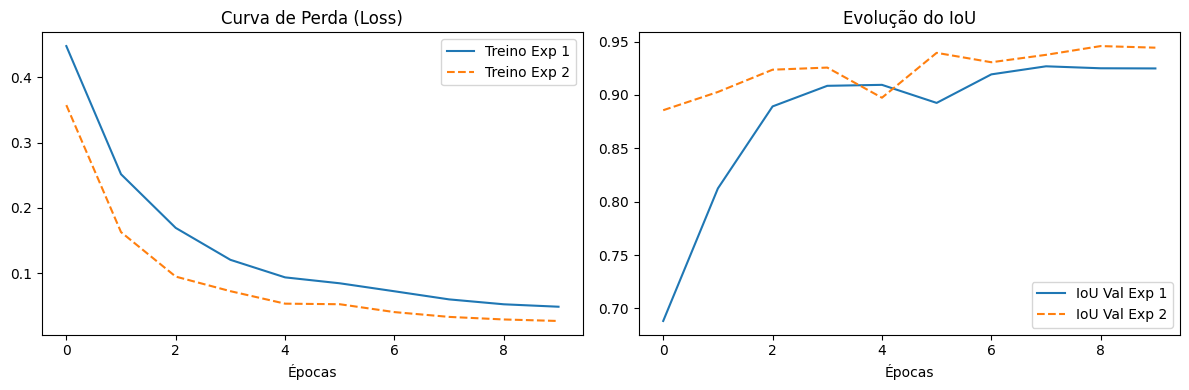

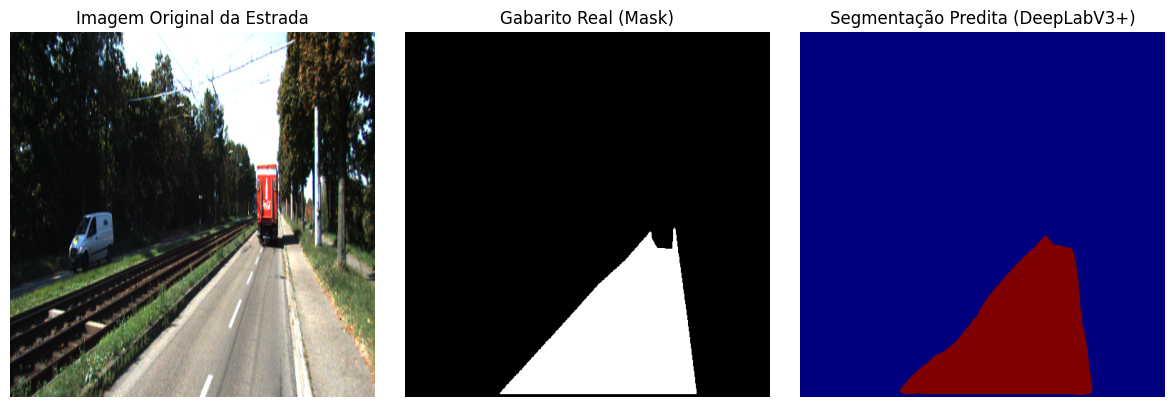

In [12]:

import matplotlib.pyplot as plt

def avaliar_no_teste(model, test_imgs_paths, test_msks_paths, size):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataset = KittiRoadDataset(test_imgs_paths, test_msks_paths, img_size=size)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    model.eval()
    total_iou, total_prec, total_rec, total_f1 = 0, 0, 0, 0

    with torch.no_grad():
        for imgs, msks in loader:
            imgs, msks = imgs.to(device), msks.to(device)
            outputs = torch.sigmoid(model(imgs))

            iou, prec, rec, f1 = calcular_metricas(outputs, msks)
            total_iou += iou
            total_prec += prec
            total_rec += rec
            total_f1 += f1

    n = len(loader)
    return total_iou/n, total_prec/n, total_rec/n, total_f1/n


metrics_exp1 = avaliar_no_teste(modelo_exp1, test_imgs, test_msks, size=256)
metrics_exp2 = avaliar_no_teste(modelo_exp2, test_imgs, test_msks, size=512)

print("\n" + "="*45)
print("       TABELA COMPARATIVA DE RESULTADOS      ")
print("="*45)
print(f"Métrica     | Exp 1 (256x256) | Exp 2 (512x512)")
print(f"IoU         | {metrics_exp1[0]:.4f}          | {metrics_exp2[0]:.4f}")
print(f"Precisão    | {metrics_exp1[1]:.4f}          | {metrics_exp2[1]:.4f}")
print(f"Recall      | {metrics_exp1[2]:.4f}          | {metrics_exp2[2]:.4f}")
print(f"F1-Score    | {metrics_exp1[3]:.4f}          | {metrics_exp2[3]:.4f}")
print("="*45)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(historico_exp1['train_loss'], label='Treino Exp 1')
plt.plot(historico_exp2['train_loss'], label='Treino Exp 2', linestyle='--')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Épocas')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historico_exp1['val_iou'], label='IoU Val Exp 1')
plt.plot(historico_exp2['val_iou'], label='IoU Val Exp 2', linestyle='--')
plt.title('Evolução do IoU')
plt.xlabel('Épocas')
plt.legend()
plt.tight_layout()
plt.show()


dataset_visual = KittiRoadDataset(test_imgs, test_msks, img_size=512)
img, msk = dataset_visual[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_exp2.eval()
with torch.no_grad():
    pred = torch.sigmoid(modelo_exp2(img.unsqueeze(0).to(device)))
    pred_bin = (pred > 0.5).cpu().squeeze().numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img.numpy().transpose(1, 2, 0))
plt.title("Imagem Original da Estrada")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(msk.squeeze().numpy(), cmap='gray')
plt.title("Gabarito Real (Mask)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(pred_bin, cmap='jet')
plt.title("Segmentação Predita (DeepLabV3+)")
plt.axis('off')
plt.tight_layout()
plt.show()